In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/context_features_dataset.csv")

print(df.shape)
df.head()

(10000, 23)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,RNF,timestamp,Ambient_Temperature,Load_Density,Humidity,Shift,Day_Type,temp_diff,load_ratio,humidity_impact
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,2025-01-01 00:00:00,26,62,41,Evening,Weekday,10.5,0.62,25.42
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,2025-01-01 00:01:00,39,34,47,Morning,Weekend,10.5,0.34,15.98
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,2025-01-01 00:02:00,34,43,81,Evening,Weekday,10.4,0.43,34.83
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,2025-01-01 00:03:00,30,97,46,Evening,Weekend,10.4,0.97,44.62
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,2025-01-01 00:04:00,27,76,49,Morning,Weekday,10.5,0.76,37.24


In [3]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift',
       'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact'],
      dtype='str')


In [4]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

print(numeric_df.shape)

(10000, 18)


In [5]:
corr = numeric_df.corr()
corr.head()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Ambient_Temperature,Load_Density,Humidity,temp_diff,load_ratio,humidity_impact
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954,0.004605,0.003880,-0.010825,0.246210,0.003880,-0.000100
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688,0.024719,-0.007180,-0.008926,-0.699583,-0.007180,-0.011593
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279,0.022007,-0.002297,-0.012940,-0.268413,-0.002297,-0.008423
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088,-0.002362,-0.005968,-0.012310,-0.016727,-0.005968,-0.010413
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136,-0.006038,0.000790,0.011336,0.006690,0.000790,0.005976


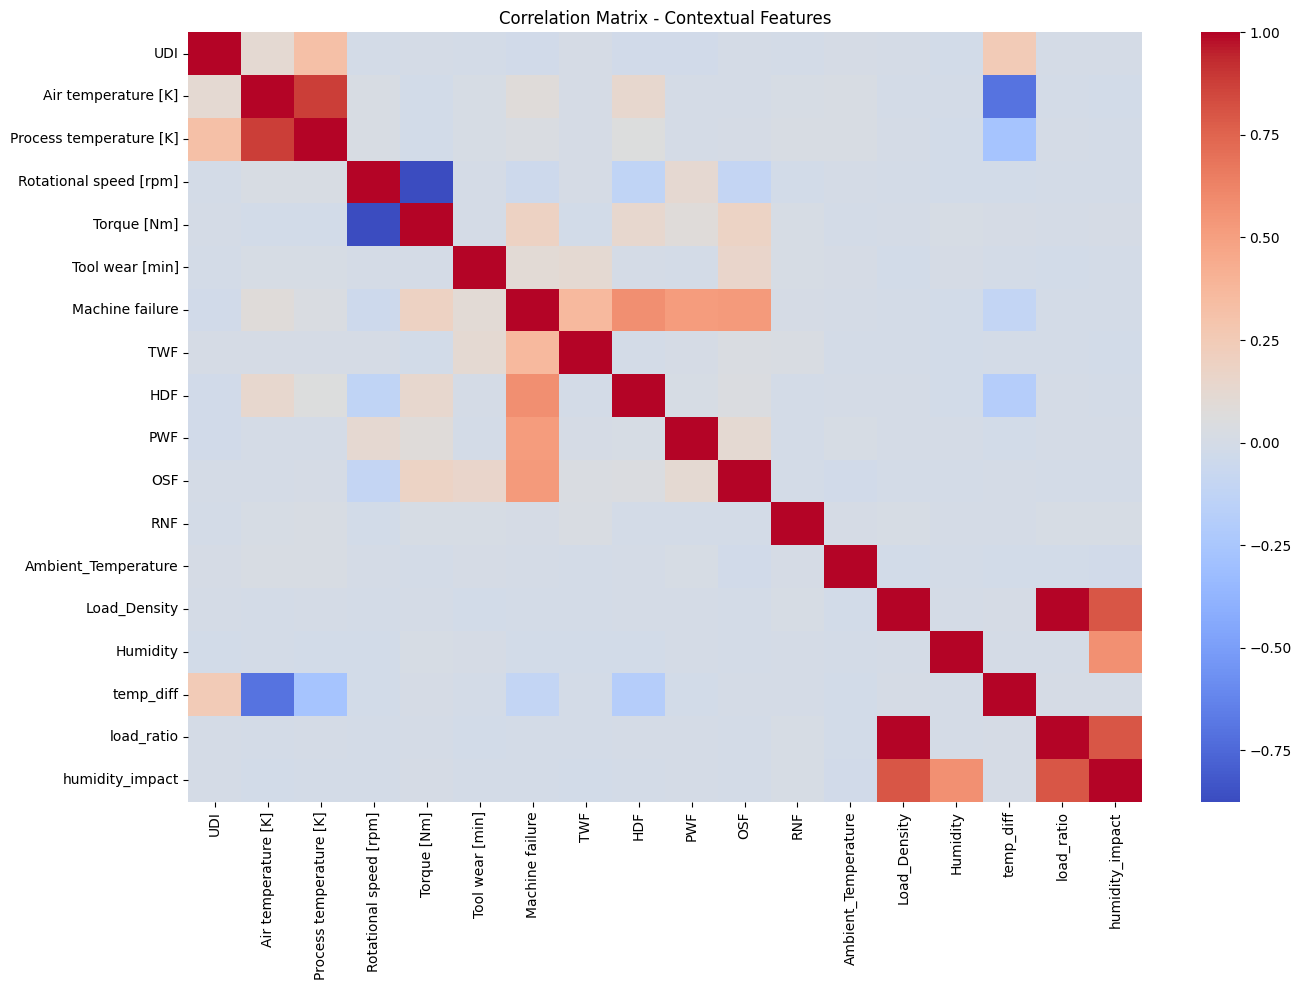

In [9]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Contextual Features")
plt.tight_layout()

plt.savefig("../reports/heatmap.png")
plt.show()

In [10]:
failure_corr = corr["Machine failure"].sort_values(
    ascending=False
)

print(failure_corr)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
Ambient_Temperature       -0.000924
load_ratio                -0.003880
Load_Density              -0.003880
humidity_impact           -0.010578
Humidity                  -0.012319
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
temp_diff                 -0.111676
Name: Machine failure, dtype: float64


In [11]:
print(
    failure_corr.head(10)
)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
Name: Machine failure, dtype: float64


In [12]:
print(
    corr.loc[
        ["temp_diff",
         "load_ratio",
         "humidity_impact"],
        ["Machine failure"]
    ]
)

                 Machine failure
temp_diff              -0.111676
load_ratio             -0.003880
humidity_impact        -0.010578


In [13]:
print("Correlation Analysis Complete")
print("Dataset Shape:", df.shape)
print("Features Analyzed:", len(df.columns))

Correlation Analysis Complete
Dataset Shape: (10000, 23)
Features Analyzed: 23


In [14]:
failure_corr = corr["Machine failure"].sort_values(ascending=False)
print(failure_corr.head(10))

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
Name: Machine failure, dtype: float64
